1. Imports
2. Load dataset
3. Understand dataset
4. Select features
5. Select target
6. Check missing values
7. Check target distribution
8. Train/Test split
9. Preprocessing
10. Train XGBoost
11. Predictions
12. Evaluation
13. Confusion Matrix
14. AUC-ROC
15. SHAP Explainability
16. Feature Importance
17. Save Model
18. Save Preprocessing

In [3]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split

In [4]:
df = pd.read_csv("../datasets/processed/dataco_features.csv")

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (180519, 50)


,type,days_for_shipping_real,days_for_shipment_scheduled,benefit_per_order,sales_per_customer,delivery_status,late_delivery_risk,category_id,category_name,customer_city,...,product_name,product_price,shipping_date_dateorders,shipping_mode,order_hour,order_day_of_week,order_month,is_weekend,shipping_delay_days,shipping_mode_delay_rate
0,CASH,2,4,88.790001,239.979996,Advance shipping,0,43,Camping & Hiking,Hickory,...,Diamondback Women's Serene Classic Comfort Bi,299.980011,2015-01-03 00:00:00,Standard Class,0,3,1,0,-2,NaN
1,PAYMENT,3,4,91.180000,193.990005,Advance shipping,0,48,Water Sports,Chicago,...,Pelican Sunstream 100 Kayak,199.990005,2015-01-04 00:21:00,Standard Class,0,3,1,0,-1,0.0
2,PAYMENT,3,4,68.250000,227.500000,Advance shipping,0,24,Women's Apparel,Chicago,...,Nike Men's Dri-FIT Victory Golf Polo,50.000000,2015-01-04 00:21:00,Standard Class,0,3,1,0,-1,0.0
3,PAYMENT,3,4,36.470001,107.889999,Advance shipping,0,18,Men's Footwear,Chicago,...,Nike Men's CJ Elite 2 TD Football Cleat,129.990005,2015-01-04 00:21:00,Standard Class,0,3,1,0,-1,0.0
4,CASH,5,4,33.590000,159.940002,Late delivery,1,46,Indoor/Outdoor Games,San Antonio,...,O'Brien Men's Neoprene Life Vest,49.980000,2015-01-06 01:03:00,Standard Class,1,3,1,0,1,0.0


In [5]:
features = [
    "order_hour",
    "order_day_of_week",
    "order_month",
    "is_weekend",
    "days_for_shipment_scheduled",
    "shipping_mode",
    "market",
    "order_region",
    "customer_segment",
    "sales",
    "order_profit_per_order",
    "order_item_quantity",
    "shipping_mode_delay_rate",
]

target = "late_delivery_risk"

X = df[features].copy()
y = df[target].copy()

print("Feature shape:", X.shape)
print("Target shape:", y.shape)
print("\nFeatures:")
print(features)
print("\nTarget distribution:")
print(y.value_counts())

Feature shape: (180519, 13)
Target shape: (180519,)

Features:
['order_hour', 'order_day_of_week', 'order_month', 'is_weekend', 'days_for_shipment_scheduled', 'shipping_mode', 'market', 'order_region', 'customer_segment', 'sales', 'order_profit_per_order', 'order_item_quantity', 'shipping_mode_delay_rate']

Target distribution:
late_delivery_risk
1    98977
0    81542
Name: count, dtype: int64


In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X,y, test_size=0.20, random_state=42, stratify=y
)
# stratify=y keeps approximately the same 54.83% / 45.17% distribution in both training and testing sets.

print("Training features:", X_train.shape)
print("Testing features:", X_test.shape)
print("Training target:", y_train.shape)
print("Testing target:", y_test.shape)

Training features: (144415, 13)
Testing features: (36104, 13)
Training target: (144415,)
Testing target: (36104,)


In [7]:
numerical_features = [
    "order_hour",
    "order_day_of_week",
    "order_month",
    "is_weekend",
    "days_for_shipment_scheduled",
    "sales",
    "order_profit_per_order",
    "order_item_quantity",
    "shipping_mode_delay_rate",
]

categorical_features = [
    "shipping_mode",
    "market",
    "order_region",
    "customer_segment",
]

print("Numerical features:", len(numerical_features))
print("Categorical features:", len(categorical_features))

Numerical features: 9
Categorical features: 4


In [8]:


from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

numerical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        # Fill missing categorical values
        ("encoder", OneHotEncoder(handle_unknown="ignore")),
        # converts categories into numerical columns.
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numerical_transformer, numerical_features),
        ("cat", categorical_transformer, categorical_features),
    ]
)

print("Preprocessing pipeline created successfully.")

Preprocessing pipeline created successfully.


In [9]:
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("Processed training shape:", X_train_processed.shape)
print("Processed testing shape:", X_test_processed.shape)

Processed training shape: (144415, 44)
Processed testing shape: (36104, 44)


In [10]:
from xgboost import XGBClassifier

model = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="logloss",
    n_jobs=-1
)

print("XGBoost classifier created successfully.")

XGBoost classifier created successfully.


In [11]:
model.fit(
    X_train_processed,
    y_train
)

print("XGBoost model trained successfully.")

XGBoost model trained successfully.


In [13]:
y_pred = model.predict(X_test_processed)
y_pred_proba = model.predict_proba(X_test_processed)[:, 1]

print("Predictions generated successfully.")
print("Predicted classes:", y_pred[:10])
print("Predicted probabilities:", y_pred_proba[:10])

Predictions generated successfully.
Predicted classes: [1 0 0 0 0 0 1 0 0 0]
Predicted probabilities: [0.71329176 0.37190774 0.43982288 0.40248236 0.3892784  0.34436408
 0.70760274 0.41577622 0.39600855 0.3299103 ]


In [14]:
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    roc_auc_score,
)

accuracy = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc_roc = roc_auc_score(y_test, y_pred_proba)

print(f"Accuracy : {accuracy:.4f}")
print(f"F1 Score : {f1:.4f}")
print(f"AUC-ROC  : {auc_roc:.4f}")

# Accuracy
# How many predictions were correct overall?


# F1 Score
# Balances:
# Precision + Recall

# AUC-ROC
# Measures how well the model distinguishes:

Accuracy : 0.7215
F1 Score : 0.7027
AUC-ROC  : 0.7982


Confusion Matrix:
[[14166  2142]
 [ 7914 11882]]


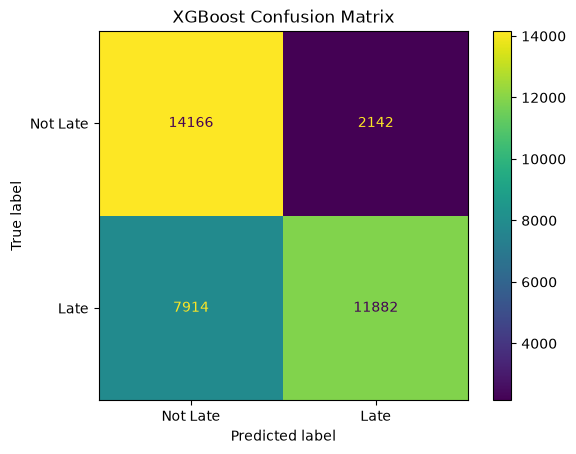

In [15]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Not Late", "Late"]
)

disp.plot()
plt.title("XGBoost Confusion Matrix")
plt.show()

In [16]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        y_pred,
        target_names=["Not Late", "Late"]
    )
)

              precision    recall  f1-score   support

    Not Late       0.64      0.87      0.74     16308
        Late       0.85      0.60      0.70     19796

    accuracy                           0.72     36104
   macro avg       0.74      0.73      0.72     36104
weighted avg       0.75      0.72      0.72     36104



In [17]:
import shap
explainer = shap.TreeExplainer(model)

X_test_sample = X_test_processed[:2000]

shap_values = explainer.shap_values(X_test_sample)

print("SHAP values calculated successfully.")
print("SHAP shape:", shap_values.shape)

SHAP values calculated successfully.
SHAP shape: (2000, 44)


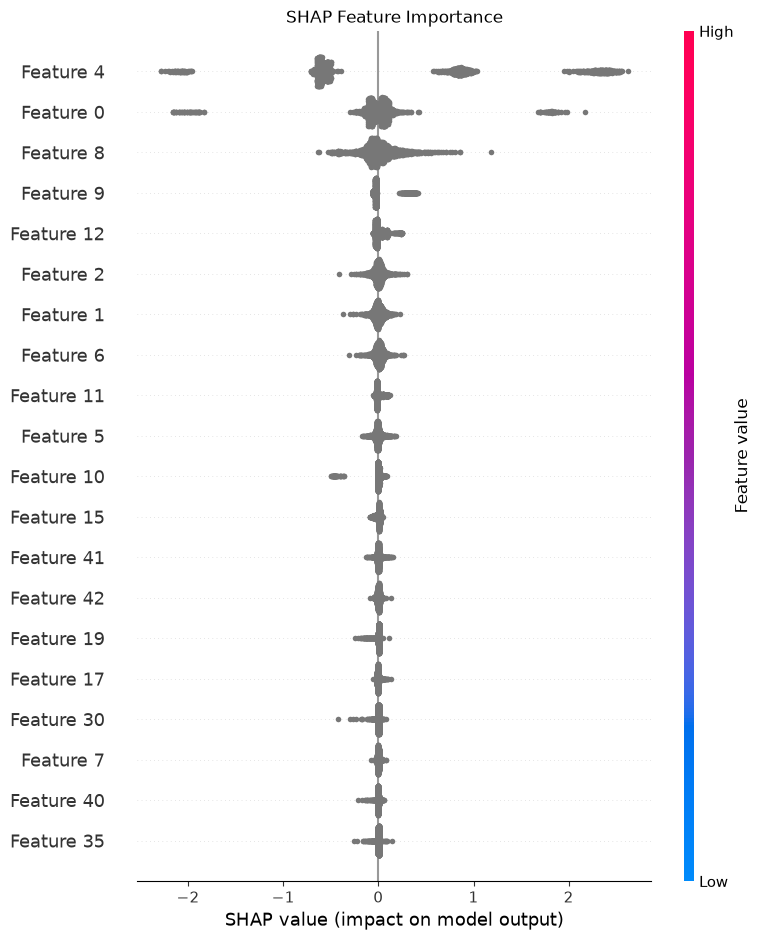

In [ ]:
shap.summary_plot(
    shap_values,
    X_test_sample,
    show=False
)

plt.title("SHAP Feature Importance")
plt.tight_layout()
plt.show()

In [ ]:
feature_names = preprocessor.get_feature_names_out()

X_test_sample_df = pd.DataFrame(
    X_test_sample.toarray(),
    columns=feature_names
)

print("Number of processed features:", len(feature_names))

print("\nProcessed feature names:")

print(feature_names)

Number of processed features: 44

Processed feature names:
['num__order_hour' 'num__order_day_of_week' 'num__order_month'
 'num__is_weekend' 'num__days_for_shipment_scheduled' 'num__sales'
 'num__order_profit_per_order' 'num__order_item_quantity'
 'num__shipping_mode_delay_rate' 'cat__shipping_mode_First Class'
 'cat__shipping_mode_Same Day' 'cat__shipping_mode_Second Class'
 'cat__shipping_mode_Standard Class' 'cat__market_Africa'
 'cat__market_Europe' 'cat__market_LATAM' 'cat__market_Pacific Asia'
 'cat__market_USCA' 'cat__order_region_Canada'
 'cat__order_region_Caribbean' 'cat__order_region_Central Africa'
 'cat__order_region_Central America' 'cat__order_region_Central Asia'
 'cat__order_region_East Africa' 'cat__order_region_East of USA'
 'cat__order_region_Eastern Asia' 'cat__order_region_Eastern Europe'
 'cat__order_region_North Africa' 'cat__order_region_Northern Europe'
 'cat__order_region_Oceania' 'cat__order_region_South America'
 'cat__order_region_South Asia' 'cat__order_r

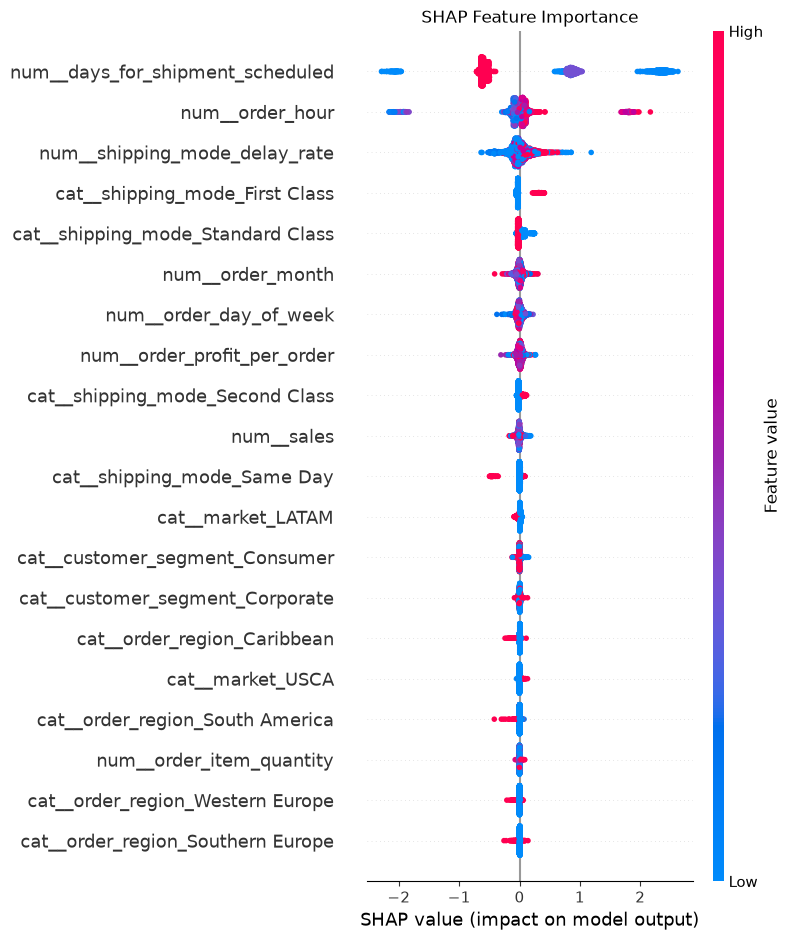

In [ ]:
shap.summary_plot(
    shap_values,
    X_test_sample_df,
    show=False
)

plt.title("SHAP Feature Importance")
plt.tight_layout()
plt.show()

In [20]:
import joblib
from pathlib import Path

model_dir = Path("../app/ai/ml/models")
model_dir.mkdir(parents=True, exist_ok=True)

joblib.dump(model, model_dir / "delay_xgboost_model.joblib")
joblib.dump(preprocessor, model_dir / "delay_preprocessor.joblib")

print("Model and preprocessor saved successfully.")
print("Model path:", model_dir / "delay_xgboost_model.joblib")
print("Preprocessor path:", model_dir / "delay_preprocessor.joblib")

Model and preprocessor saved successfully.
Model path: ..\app\ai\ml\models\delay_xgboost_model.joblib
Preprocessor path: ..\app\ai\ml\models\delay_preprocessor.joblib


In [21]:
import joblib
loaded_model = joblib.load(model_dir / "delay_xgboost_model.joblib")
loaded_preprocessor = joblib.load(model_dir / "delay_preprocessor.joblib")

print("Model loaded successfully.")
print("Preprocessor loaded successfully.")

Model loaded successfully.
Preprocessor loaded successfully.


In [22]:
sample_features = X_test.iloc[[0]]

sample_processed = loaded_preprocessor.transform(sample_features)

sample_prediction = loaded_model.predict(sample_processed)[0]
sample_probability = loaded_model.predict_proba(sample_processed)[0, 1]

print("Predicted class:", sample_prediction)
print("Delay probability:", round(float(sample_probability), 4))

Predicted class: 1
Delay probability: 0.7133
